# Lab #6: Principal Component Analysis

In this lab, we use scikit-learn to implement principal component analysis (PCA). We first load the Python libraries that will be used, as well as the lodgepole pine data.

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
data = pd.read_csv('lodgepole_data.csv')

Before we implement PCA, we follow the same data pre-processing steps as in the previous labs.

In [31]:
X = data.drop('lodgepole_pine', axis=1)
y = data['lodgepole_pine']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=123)

In [32]:
encoder = OneHotEncoder(handle_unknown='ignore')
encoder.fit(X_train[['wilderness_area', 'soil_type']])
encoded_df = pd.DataFrame(encoder.transform(X_train[['wilderness_area', 'soil_type']]).toarray(),
                          columns=encoder.get_feature_names_out(['wilderness_area', 'soil_type']))
X_train = pd.concat([X_train.drop(['wilderness_area', 'soil_type'], axis=1).reset_index(drop=True), encoded_df], axis=1)

In [33]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [34]:
encoded_df = pd.DataFrame(encoder.transform(X_test[['wilderness_area', 'soil_type']]).toarray(),
                          columns=encoder.get_feature_names_out(['wilderness_area', 'soil_type']))
X_test = pd.concat([X_test.drop(['wilderness_area', 'soil_type'], axis=1).reset_index(drop=True), encoded_df], axis=1)
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)

Note, as discussed in the live session, the scaling of the training and test sets above is critical for PCA. Now that the features are scaled, we implement PCA in scikit-learn using the 'PCA' function. The numerical features are contained in the first 10 columns of the data, so we run PCA only on the first 10 columns.

In [35]:
principal = PCA()
principal.fit(X_train_scaled.iloc[:, 0:10])

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


To obtain the amount of variance explained by each principal component (PC), as well as the proportion of the variance explained by each PC, we can use the 'explained_variance_' and 'explained_variance_ratio' attributes of the PCA object, respectively. In this example, the first PC explains about 26% of the variance. This output can be used to select the number of PCs that explain enough of the variance.

In [36]:
principal.explained_variance_

array([2.64354967, 2.09807278, 1.73767156, 1.07502066, 0.76820311,
       0.5526785 , 0.46673225, 0.3502298 , 0.30663305, 0.00273862])

In [37]:
principal.explained_variance_ratio_

array([0.26431453, 0.20977518, 0.17374057, 0.10748562, 0.07680856,
       0.0552594 , 0.04666608, 0.03501762, 0.03065861, 0.00027382])

However, a scree plot is more convenient.

Text(0, 0.5, 'Explained Variance')

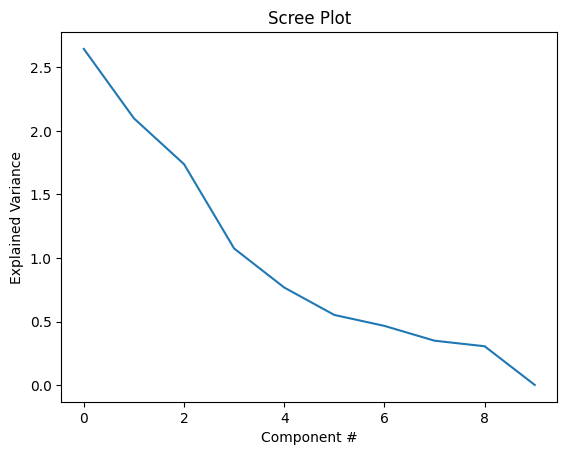

In [38]:
plt.plot(principal.explained_variance_)
plt.title('Scree Plot')
plt.xlabel('Component #')
plt.ylabel('Explained Variance')

In the scree plot, we look for an elbow in the curve to help us choose the number of PCs that explain enough of the variance. However, as can be seen in the plot above, it is not always straightforward to identify the elbow; unsupervised learning is much more subjective than supervised learning and sometimes depends on the judgement of the analyst. In the plot above, the first 6 PCs seem to explain enough of the variance (almost 90%). Therefore, we can try reducing the number of numerical features from 10 to 6. The new 6 features are the projections of the original observations onto the first 6 PCs.

To project observations onto the PCs, we use the 'transform' method of the fitted 'principal' PCA object. In the code below, the dataframe 'latent_features' contains the projections of the observations in the training set onto the PCs. In particular, each column in 'latent_features' contains the projection onto the corresponding PC: the first column in 'latent_features' contains the projection of the observations onto the first PC, the second column in 'latent_features' contains the projection of the observations onto the second PC, etc.

In [39]:
latent_features = pd.DataFrame(principal.transform(X_train_scaled.iloc[:, 0:10]))

After we project the observations onto the PCs, we take only the first 6 columns (since we only want to use the first 6 PCs) and append the non-numerical features in the training set to get the new training set, called 'X_train_PCA'.

In [40]:
X_train_PCA = pd.concat([latent_features.iloc[:, 0:6].reset_index(drop=True), X_train_scaled.iloc[:, 10:].reset_index(drop=True)], axis=1)

To project the observations in the test set onto the first 6 PCs, we perform the same operation as above on the test set. In particular, we use the 'transform' method on the 'principal' object that was obtained using PCA on the training set (remember, everything is based on the training set!).

In [41]:
latent_features = pd.DataFrame(principal.transform(X_test_scaled.iloc[:, 0:10]))
X_test_PCA = pd.concat([latent_features.iloc[:, 0:6].reset_index(drop=True), X_test_scaled.iloc[:, 10:].reset_index(drop=True)], axis=1)

Now that the training and test sets each have the 6 new features obtained using PCA, we can try using these 6 new numerical features instead of the original 10. The code below is from the Module #5 live session, now using the 'X_train_PCA' and 'X_test_PCA' data sets. Note, there are now 48 input features into the input layer of the feedforward neural network.

In [42]:
X_train_tensor = torch.tensor(X_train_PCA.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_PCA.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [43]:
n_samples = X_train_tensor.shape[0]
n_val = int(0.2 * n_samples)
shuffled_indices = torch.randperm(n_samples)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]
train_indices, val_indices

X_tr = X_train_tensor[train_indices]
y_tr = y_train_tensor[train_indices]
X_val = X_train_tensor[val_indices]
y_val = y_train_tensor[val_indices]

In [44]:
seq_model = nn.Sequential(
    nn.Linear(48, 75),
    nn.ReLU(),
    nn.Linear(75, 50),
    nn.ReLU(),
    nn.Linear(50, 1),
    nn.Sigmoid())
seq_model

Sequential(
  (0): Linear(in_features=48, out_features=75, bias=True)
  (1): ReLU()
  (2): Linear(in_features=75, out_features=50, bias=True)
  (3): ReLU()
  (4): Linear(in_features=50, out_features=1, bias=True)
  (5): Sigmoid()
)

In [45]:
def training_loop(n_epochs, optimizer, model, loss_fn, X_tr, X_val, y_tr, y_val):
    for epoch in range(1, n_epochs + 1):
        X_tr_p = model(X_tr)
        loss_train = loss_fn(X_tr_p, y_tr.unsqueeze(1))
        
        X_val_p = model(X_val)
        loss_val = loss_fn(X_val_p, y_val.unsqueeze(1))
        
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()
        
        if epoch == 1 or epoch % 100 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"f" Validation loss {loss_val.item():.4f}")

In [46]:
optimizer = optim.Adam(seq_model.parameters(), lr=1e-3)
training_loop(
    n_epochs = 200,
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.BCELoss(),
    X_tr = X_tr,
    X_val = X_val,
    y_tr = y_tr,
    y_val = y_val)

Epoch 1, Training loss 0.7047, Validation loss 0.7033
Epoch 100, Training loss 0.4710, Validation loss 0.5008
Epoch 200, Training loss 0.4079, Validation loss 0.4866


In [47]:
p_1_actual = pd.DataFrame({'p_1': seq_model(X_test_tensor).detach().numpy().reshape(-1), 'actual': y_test})
p_1_actual.head()

,p_1,actual
2151,0.786146,1
340,0.902288,1
8087,0.019652,0
6059,0.380381,0
5153,0.233208,0


In [48]:
roc_data = pd.DataFrame({'threshold': np.arange(1, -0.01, -0.01), 'fpr': 0.0, 'tpr': 0.0})
for i in np.arange(1, -0.01, -0.01):

    over_threshold = p_1_actual[p_1_actual['p_1'] >= i]

    fp = len(over_threshold[over_threshold['actual']==0])
    actuals_0 = len(p_1_actual[p_1_actual['actual']==0])
    fpr = fp/actuals_0

    roc_data.loc[roc_data['threshold'] == i, 'fpr'] = fpr

    tp = len(over_threshold[over_threshold['actual']==1])
    actuals_1 = len(p_1_actual[p_1_actual['actual']==1])
    tpr = tp/actuals_1
    
    roc_data.loc[roc_data['threshold'] == i, 'tpr'] = tpr

roc_data
  

,threshold,fpr,tpr
0,1.000000e+00,0.000000,0.000000
1,9.900000e-01,0.002732,0.007401
2,9.800000e-01,0.002732,0.010176
3,9.700000e-01,0.002732,0.017576
4,9.600000e-01,0.004554,0.033302
...,...,...,...
96,4.000000e-02,0.803279,0.995375
97,3.000000e-02,0.834244,0.996300
98,2.000000e-02,0.864299,0.997225
99,1.000000e-02,0.897996,0.998150


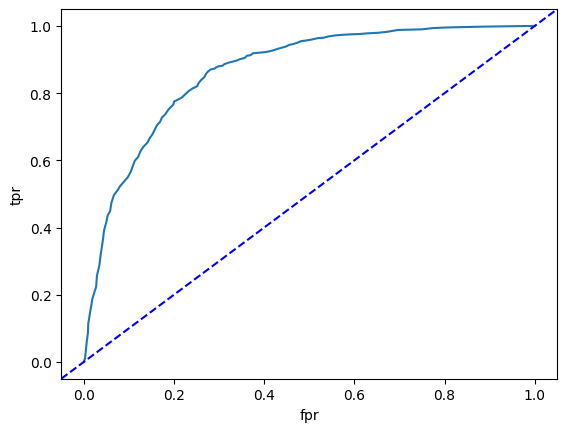

In [49]:
roc = sns.lineplot(x='fpr', y='tpr', data=roc_data)
plt.xlim(-0.05, 1.05)

xlims = roc.get_xlim()
ylims = roc.get_ylim()

min_val = min(xlims[0], ylims[0])
max_val = max(xlims[1], ylims[1])

roc.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='blue')

roc.set_xlim(xlims)
roc.set_ylim(ylims)

plt.show()

Comparing the ROC curve and AUC above to the ROC curve and AUC for the original dense feed-forward neural network in the live session code for Module #5, we can see that both models are essentially indistinguishable, even though we used a reduced number of features in this lab. This is because the 6 new features (based on the first 6 PCs) account for almost 90% of the variation in the original 10 features.

## Exercises

Hint for all exercises: see the live session slides for Module #7.

#### What is the main difference between unsupervised and supervised learning?

The main difference between supervised and unsupervised learning is that unsupervised learning does not contain a response variable. Instead of trying to identify trends in the observations that lead to a prediction of the response variable, unsupervised learning aims to identify groups or features in the observations themselves. An example of this would be k-Means clustering, where the observations are grouped based on commonalities between them.

#### Is centering required for PCA? Is scaling required for PCA? Explain your answers.

Centering is the act of subtracting the mean from the data. In the case of a PCA analysis, this is a helpful tool to ensure that the principle components are measuring the maximum variance. Variance is independent of mean, therefore centering removes mean and creates a meaningful first principle component (which would otherwise be a vector pointing to 0,0). This is a required practice.

Scaling is the act of dividing by the standard deviation, which should be done in cases where the features are of different scales. Without scaling, the greater magnitude features will be measured disproportionately in the PCA analysis, corrupting the results. This is only required, as mentioned before, if the features are of different magnitudes.

#### After running the code above, run the following code to obtain the PCA feature loadings. Copy and paste the output. Which feature has the strongest influence on the first PC? Which feature has the weakest influence on the first PC?

In [ ]:
pd.DataFrame(principal.components_)

,0,1,2,3,4,5,6,7,8,9
0,0.148157,0.482796,-0.113950,0.120509,0.082296,0.138691,-0.437618,0.394611,0.585984,-0.028975
1,-0.340752,0.167293,0.527579,0.010902,0.246153,-0.379282,-0.371782,-0.343382,0.040675,-0.339425
2,0.356243,-0.095998,0.125743,0.646217,0.600799,0.155480,0.048686,-0.116007,-0.120042,0.122865
3,0.043929,0.074338,0.371467,-0.229597,-0.138418,0.518716,-0.287001,-0.353210,-0.005336,0.553589
4,-0.606694,-0.014863,-0.162793,0.158355,0.206038,-0.284221,0.022543,0.152185,0.086366,0.652505
5,-0.567308,-0.029395,0.012718,0.005560,0.231698,0.672172,0.145776,0.170219,-0.045487,-0.345415
6,0.076486,0.660943,0.365059,-0.122232,0.068157,-0.071483,0.458284,0.287868,-0.306494,0.111851
7,-0.159499,0.501863,-0.414257,0.409001,-0.315209,0.076002,0.008094,-0.492358,-0.177346,-0.068817
8,0.108985,0.185425,-0.454132,-0.554722,0.593615,-0.013508,-0.015173,-0.290564,-0.049971,0.008460
9,-0.003896,-0.000072,0.130771,-0.001105,0.000766,0.002264,0.594517,-0.355401,0.709305,-0.001520


The first PC is comprised of column one, where each of the row values represent the influence of the corresponding feature. Feature 5 (at index 4) has the strongest influence on the first principle component with a loading of -0.6067. Feature 4 (at index 3) has the lowest influence, as it is nearest to 0. The strength of the influence is based on the absolute value of the feature loadings.